# Cavità acustica + piastra flessibile: accoppiamento vibroacustico

Caso canonico: una scatola d'aria chiusa da 5 pareti rigide, la sesta è una piastra d'acciaio flessibile.

```
        piastra flessibile (z = Lz)
    ┌───────────────────────────┐
    │                           │
    │      aria, cavità         │  ← pareti rigide
    │      Lx × Ly × Lz         │
    └───────────────────────────┘
```

Le due interazioni avvengono contemporaneamente:

$$p \;\longrightarrow\; \text{forza sulla piastra} \;\longrightarrow\; w \;\longrightarrow\; v_n = j\omega\, n\cdot w \;\longrightarrow\; p$$

Nel notebook:

1. mesh conforme con gmsh;
2. i due domini e la matrice di accoppiamento $K_c$;
3. modi accoppiati vs disaccoppiati;
4. **confronto appoggio semplice S-S-S-S vs incastro C-C-C-C**;
5. risposta forzata e campo di pressione 3D.

In [1]:
import pathlib
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh

REPO = pathlib.Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "coupling_geometry"))

import pycafe
from pycafe.core.prepare_vibroacoustic_system import prepare_vibroacoustic_system
from pycafe.solver.solver_modale import solve_modal_acoustic_reduced
from pycafe.solver.solver_vibroacoustic import (
    build_coupled_blocks,
    expand_pressure,
    solve_vibroacoustic_frequency_sweep,
    solve_vibroacoustic_modal,
    structural_displacement_field,
)
from pycafe.post_processing.post_processing_3d import (
    animate_pressure_3d,
    default_movie_extension,
    plot_pressure_3d,
)

# Cavità e piastra
LX, LY, LZ = 0.8, 0.6, 0.5          # m
NX, NY, NZ = 8, 6, 5                # elementi per direzione
RHO0, C0 = 1.204, 343.0             # aria
T, RHO_S, E, NU = 0.002, 7800.0, 210e9, 0.3   # acciaio 2 mm

V_CAVITA = LX * LY * LZ
A_PIASTRA = LX * LY
print(f"cavità {V_CAVITA:.3f} m³, piastra {A_PIASTRA:.3f} m²")

cavità 0.240 m³, piastra 0.480 m²


## 1. Mesh conforme

La piastra **non** è una superficie duplicata: i suoi QUAD4 sono esattamente le facce superiori degli HEXA8 del fluido, con gli stessi tag nodali. È questo che permette di integrare $K_c$ sulle facce condivise senza alcuna interpolazione tra griglie diverse.

In [2]:
from make_box_plate_mesh import make_box_plate_mesh

# verbose=False: senza, gmsh stampa una riga "Info :" per ogni passo
msh = make_box_plate_mesh(
    Lx=LX, Ly=LY, Lz=LZ, nx=NX, ny=NY, nz=NZ,
    output_path="box_plate_nb.msh", verbose=False,
)
nodes, elements, boundaries, groups = pycafe.load_mesh_with_groups(
    str(msh), verbose=False
)

print(f"{nodes.shape[0]} nodi\n")
print("physical groups:")
for name, g in groups.items():
    tipi = {k: v.shape[0] for k, v in g["elements"].items()}
    print(f"  {name:<14} dim {g['dim']}  {tipi}")

print("\nnodi piastra ⊂ nodi fluido:",
      set(groups["plate"]["nodes"]) <= set(groups["fluid"]["nodes"]))

378 nodi

physical groups:
  plate_clamp    dim 1  {'Line 2': 28}
  plate          dim 2  {'Quadrilateral 4': 48}
  rigid_walls    dim 2  {'Quadrilateral 4': 188}
  fluid          dim 3  {'Hexahedron 8': 240}

nodi piastra ⊂ nodi fluido: True


## 2. Domini + accoppiamento

`prepare_vibroacoustic_system` assembla i due domini e, di default, la matrice di accoppiamento

$$K_c = \int_S N_s^T\, n\, N_a \; dS$$

con $n$ **uscente dal fluido** (orientata in automatico guardando l'esaedro dietro ogni faccia). Da lì:

* forza sulla struttura: $F_s = K_c\, p$
* sorgente acustica: $F_a = \rho_0\omega^2 K_c^T w$

Il sistema è quindi non simmetrico — un accoppiamento sta nel blocco di rigidezza, l'altro in quello di massa:

$$\begin{bmatrix} K_s - \omega^2 M_s & -K_c \\ -\rho_0\omega^2 K_c^T & K_a - \omega^2 M_a\end{bmatrix}\begin{Bmatrix} w \\ p \end{Bmatrix} = \begin{Bmatrix} F_s \\ F_a \end{Bmatrix}$$

In [3]:
def costruisci(support):
    """Sistema accoppiato con il vincolo di bordo richiesto."""
    return prepare_vibroacoustic_system(
        nodes=nodes, groups=groups,
        rho0=RHO0, c0=C0,
        t=T, rho_s=RHO_S, E=E, nu=NU,
        support=support,
    )


sistema = costruisci("clamped")
Kc = sistema["coupling"]["Kc"]

print(f"Kc: {Kc.shape}, nnz {Kc.nnz}")
print(f"normale interfaccia: {sistema['interface']['normals'][0]}")
print(f"∫ n dS = {np.round(sistema['coupling']['area_vector'], 6)} m²"
      f"   (attesa {A_PIASTRA:.4f} lungo +z)")
print(f"Mc = -ρ₀ Kcᵀ : {sistema['coupling']['Mc'].shape}")

Kc: (2268, 378), nnz 1425
normale interfaccia: [-0.  0.  1.]
∫ n dS = [0.   0.   0.48] m²   (attesa 0.4800 lungo +z)
Mc = -ρ₀ Kcᵀ : (378, 2268)


La somma delle colonne di $K_c$ è l'**area vettoriale** dell'interfaccia: applicare una pressione unitaria uniforme deve dare una risultante pari a $\int_S n\,dS$. È il controllo più economico che orientamento e jacobiano di superficie siano giusti.

## 3. Modi accoppiati vs disaccoppiati

Tre calcoli a confronto:

| | cosa vede |
|---|---|
| piastra in vacuo | solo $K_s, M_s$ |
| cavità rigida | solo $K_a, M_a$ |
| **accoppiato** | tutto, con $K_c$ |

In [4]:
def modi_piastra(sistema, k=4):
    """Modi della piastra in vacuo."""
    K = sistema["structural"]["K_red"].tocsc()
    M = sistema["structural"]["M_red"].tocsc()
    vals, vecs = eigsh(K, k=k, M=M, sigma=0.0, which="LM")
    ordine = np.argsort(vals)
    return np.sqrt(np.abs(vals[ordine])) / (2 * np.pi), vecs[:, ordine]


f_piastra, _ = modi_piastra(sistema)
f_cavita, _ = solve_modal_acoustic_reduced(
    sistema["acoustic"]["K"], sistema["acoustic"]["M"], num_modes=3
)
f_acc, _ = solve_vibroacoustic_modal(sistema, num_modes=5)

print(f"piastra in vacuo : {np.round(f_piastra, 2)} Hz")
print(f"cavità rigida    : {np.round(f_cavita, 2)} Hz")
print(f"accoppiato       : {np.round(f_acc, 2)} Hz")
print(f"\n1° modo flessibile: {f_acc[1]:.2f} Hz contro {f_piastra[0]:.2f} Hz "
      f"in vacuo ({(f_acc[1]/f_piastra[0]-1)*100:+.1f}%)")

piastra in vacuo : [ 40.84  70.79 105.75 128.63] Hz
cavità rigida    : [215.75 289.11 348.67] Hz
accoppiato       : [  0.    43.46  70.35 105.22 128.37] Hz

1° modo flessibile: 43.46 Hz contro 40.84 Hz in vacuo (+6.4%)


### Attenzione al modo a ~0 Hz: è acustico, non è la piastra che galleggia

Con la piastra **incastrata** non esistono moti rigidi: il primo modo strutturale è a ~41 Hz, ben sopra zero. Il modo a 0 Hz del sistema accoppiato appartiene al **fluido**: è la pressione uniforme della cavità sigillata, l'equivalente acustico di un moto rigido (nessuna parete la lascia sfogare, quindi una pressione costante non costa energia).

In quel modo la piastra non è ferma, ma nemmeno si muove come corpo rigido: sta semplicemente nella sua **deflessione statica** sotto quella pressione uniforme. Verifichiamolo.

In [5]:
from scipy.sparse.linalg import spsolve

blocchi = build_coupled_blocks(sistema)
_, modi_acc = solve_vibroacoustic_modal(sistema, num_modes=2, blocks=blocchi)

n_s = blocchi["n_s"]
w0 = np.real(modi_acc[:n_s, 0])
p0 = np.real(modi_acc[n_s:, 0])

# la pressione e' costante su tutta la cavita'
print(f"pressione uniforme?   spread = {np.ptp(p0 / p0.mean()):.2e}  (0 = uniforme)")

# la piastra sta nella deflessione statica sotto quella pressione
w_statico = spsolve(
    blocchi["Ks"].tocsc(), blocchi["Kc"] @ np.full(blocchi["n_a"], p0.mean())
)
print(f"forma piastra = deflessione statica?  correlazione = "
      f"{abs(np.corrcoef(w0, w_statico)[0, 1]):.6f}")

# la piastra incastrata non ha moti rigidi: nessun DOF del bordo sopravvive
bordo = sistema["structural"]["clamped_nodes0"]
liberi = sistema["structural"]["idx_free"]
print(f"\nnodi di bordo vincolati: {len(bordo)}, "
      f"DOF di bordo ancora liberi: {np.intersect1d(liberi // 6, bordo).size}")
print(f"primo modo piastra in vacuo: {f_piastra[0]:.2f} Hz  → nessun moto rigido")

pressione uniforme?   spread = 4.00e-15  (0 = uniforme)
forma piastra = deflessione statica?  correlazione = 1.000000

nodi di bordo vincolati: 28, DOF di bordo ancora liberi: 0
primo modo piastra in vacuo: 40.84 Hz  → nessun moto rigido


L'aria intrappolata si comporta come una **molla**: comprimendosi si oppone al movimento della piastra, quindi la frequenza sale. Il valore atteso, finché si sta sotto la prima risonanza di cavità (216 Hz), è quello di una cavità compatta:

$$k_{\text{aria}} = \frac{\rho_0 c_0^2\,(\Delta V)^2}{V}, \qquad \Delta V = \int_S n\cdot\phi\; dS$$

con $\phi$ il modo della piastra in vacuo. Se il segno di $K_c$ fosse sbagliato la frequenza **scenderebbe**: è il controllo che smaschera l'errore di segno più comune.

In [6]:
def previsione_cavita_compatta(sistema):
    """Frequenza del 1° modo con l'aria trattata come molla di volume."""
    blocchi = build_coupled_blocks(sistema)
    Ks, Ms, Kc = blocchi["Ks"], blocchi["Ms"], blocchi["Kc"]

    vals, vecs = eigsh(Ks.tocsc(), k=1, M=Ms.tocsc(), sigma=0.0, which="LM")
    phi, omega_p2 = vecs[:, 0], vals[0]

    massa_modale = phi @ (Ms @ phi)
    delta_V = (Kc @ np.ones(blocchi["n_a"])) @ phi      # volume spazzato
    k_aria = RHO0 * C0**2 * delta_V**2 / V_CAVITA

    return np.sqrt(omega_p2 + k_aria / massa_modale) / (2 * np.pi), delta_V


f_molla, dV = previsione_cavita_compatta(sistema)
print(f"volume spazzato dal modo   ΔV = {dV:.4e} m³/unità modale")
print(f"previsione molla di cavità    = {f_molla:.2f} Hz")
print(f"FEM accoppiato                = {f_acc[1]:.2f} Hz")
print(f"scarto                        = {abs(f_molla-f_acc[1])/f_molla*100:.2f} %")

volume spazzato dal modo   ΔV = 1.2716e-01 m³/unità modale
previsione molla di cavità    = 43.70 Hz
FEM accoppiato                = 43.46 Hz
scarto                        = 0.54 %


## 4. Appoggio semplice (S-S-S-S) contro incastro (C-C-C-C)

Stesso bordo, vincoli diversi:

| | DOF bloccati sul bordo | effetto |
|---|---|---|
| **C-C-C-C** | tutti e 6: $u_x,u_y,u_z,r_x,r_y,r_z$ | il bordo non trasla né ruota |
| **S-S-S-S** | le 3 traslazioni | il bordo è fermo ma la piastra ci **cerniera** sopra |

Riferimenti analitici per la piastra sottile in vacuo:

$$f^{SS}_{11} = \frac{\pi}{2}\sqrt{\frac{D}{\rho t}}\left(\frac{1}{a^2}+\frac{1}{b^2}\right) \qquad\qquad f^{CC}_{11} \simeq \frac{\lambda^2}{2\pi a^2}\sqrt{\frac{D}{\rho t}},\; \lambda^2\simeq 52.5 \;\text{(Leissa)}$$

In [7]:
D = E * T**3 / (12 * (1 - NU**2))
f_ss_teorica = (np.pi / 2) * np.sqrt(D / (RHO_S * T)) * (1 / LX**2 + 1 / LY**2)
f_cc_teorica = 52.5 / (2 * np.pi * LX**2) * np.sqrt(D / (RHO_S * T))

casi = {}
for nome, support in (("S-S-S-S", "simply_supported"), ("C-C-C-C", "clamped")):
    s = costruisci(support)
    f_vac, _ = modi_piastra(s, k=4)
    f_cpl, _ = solve_vibroacoustic_modal(s, num_modes=5)
    casi[nome] = {
        "sistema": s,
        "n_dof": s["structural"]["K_red"].shape[0],
        "in_vacuo": f_vac,
        "accoppiato": f_cpl[1:],          # scarta la pressione uniforme
        "molla": previsione_cavita_compatta(s)[0],
    }

print(f"analitico  S-S-S-S f11 = {f_ss_teorica:6.2f} Hz")
print(f"analitico  C-C-C-C f11 = {f_cc_teorica:6.2f} Hz\n")

riga = "{:<9} {:>7} {:>12} {:>12} {:>9}"
print(riga.format("vincolo", "n DOF", "in vacuo", "accoppiato", "Δf"))
for nome, d in casi.items():
    f0, f1 = d["in_vacuo"][0], d["accoppiato"][0]
    print(riga.format(nome, d["n_dof"], f"{f0:8.2f} Hz", f"{f1:8.2f} Hz",
                      f"{(f1/f0-1)*100:+6.1f}%"))

analitico  S-S-S-S f11 =  21.41 Hz
analitico  C-C-C-C f11 =  41.00 Hz

vincolo     n DOF     in vacuo   accoppiato        Δf
S-S-S-S       294     21.71 Hz     27.63 Hz    +27.2%
C-C-C-C       210     40.84 Hz     43.46 Hz     +6.4%


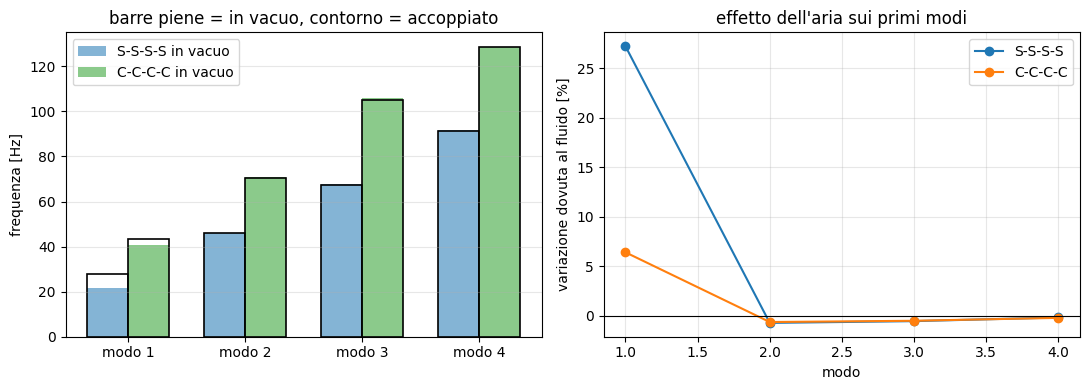

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

x = np.arange(4)
larghezza = 0.35
for i, (nome, d) in enumerate(casi.items()):
    ax1.bar(x + (i - 0.5) * larghezza, d["in_vacuo"][:4], larghezza,
            label=f"{nome} in vacuo", alpha=0.55)
    ax1.bar(x + (i - 0.5) * larghezza, d["accoppiato"][:4], larghezza,
            fill=False, edgecolor="k", linewidth=1.2)
ax1.set_xticks(x, [f"modo {i+1}" for i in x])
ax1.set_ylabel("frequenza [Hz]")
ax1.set_title("barre piene = in vacuo, contorno = accoppiato")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

for nome, d in casi.items():
    shift = (d["accoppiato"][:4] / d["in_vacuo"][:4] - 1) * 100
    ax2.plot(x + 1, shift, "o-", label=nome)
ax2.axhline(0, color="k", linewidth=0.8)
ax2.set_xlabel("modo")
ax2.set_ylabel("variazione dovuta al fluido [%]")
ax2.set_title("effetto dell'aria sui primi modi")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Due letture:

* la piastra appoggiata è **più cedevole** → frequenze in vacuo più basse, e soprattutto spazza più volume, quindi comprime di più l'aria: l'irrigidimento dovuto alla cavità è molto più marcato che nel caso incastrato;
* non tutti i modi salgono. I modi con $\Delta V \simeq 0$ (lobi di segno opposto che si compensano) non comprimono il fluido: lì domina la massa aggiunta e la frequenza scende leggermente.

In [9]:
# Volume spazzato da ogni modo: spiega chi sale e chi scende
print(f"{'vincolo':<9} {'modo':<6} {'ΔV normalizzato':>17} {'Δf':>8}")
for nome, d in casi.items():
    s = d["sistema"]
    blocchi = build_coupled_blocks(s)
    carico_unitario = blocchi["Kc"] @ np.ones(blocchi["n_a"])
    _, modi = modi_piastra(s, k=4)
    for i in range(4):
        phi = modi[:, i] / np.abs(modi[:, i]).max()
        dV = carico_unitario @ phi
        shift = (d["accoppiato"][i] / d["in_vacuo"][i] - 1) * 100
        print(f"{nome:<9} {i+1:<6} {dV:>17.3e} {shift:>7.1f}%")

vincolo   modo     ΔV normalizzato       Δf
S-S-S-S   1              3.589e-02    27.2%
S-S-S-S   2              1.588e-15    -0.7%
S-S-S-S   3             -4.847e-17    -0.5%
S-S-S-S   4             -4.684e-03    -0.2%
C-C-C-C   1              2.643e-02     6.4%
C-C-C-C   2              2.692e-16    -0.6%
C-C-C-C   3              4.245e-17    -0.5%
C-C-C-C   4              4.110e-03    -0.2%


## 5. Risposta forzata e campo di pressione

Forza puntuale di 1 N normale al centro della piastra, con smorzamento strutturale $\eta = 2\%$. La piastra vibra, la cavità si pressurizza.

In [10]:
ETA_S = 0.02
frequenze = np.arange(10.0, 120.0 + 1.0, 1.0)


def dof_centro(sistema):
    """Indice ridotto della traslazione uz al centro della piastra."""
    idx = sistema["structural"]["idx_free"]
    nodo, componente = idx // 6, idx % 6
    piastra = np.unique(nodo)
    centro = np.array([LX / 2, LY / 2, LZ])
    bersaglio = piastra[np.argmin(np.linalg.norm(nodes[piastra] - centro, axis=1))]
    return int(np.where((nodo == bersaglio) & (componente == 2))[0][0])


risposte = {}
for nome, d in casi.items():
    s = d["sistema"]
    blocchi = build_coupled_blocks(s, eta_s=ETA_S)
    dof = dof_centro(s)
    F_s = np.zeros(blocchi["n_s"])
    F_s[dof] = 1.0
    out = solve_vibroacoustic_frequency_sweep(
        s, frequenze, F_s=F_s, blocks=blocchi, verbose=False,
    )
    out["dof"] = dof
    risposte[nome] = out

print("sweep completato:", {k: v["p"].shape for k, v in risposte.items()})

sweep completato: {'S-S-S-S': (378, 111), 'C-C-C-C': (378, 111)}


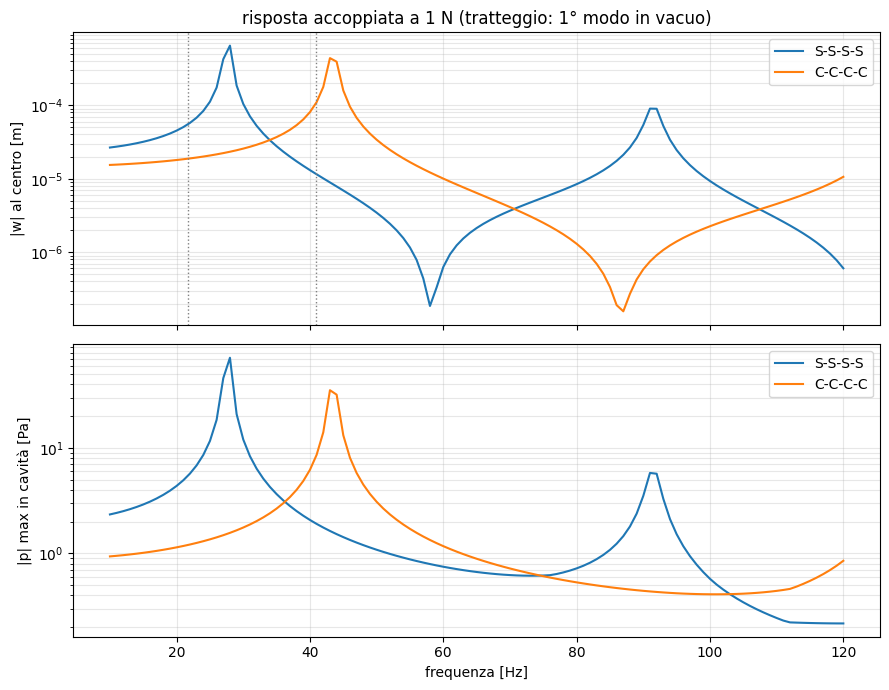

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)

for nome, out in risposte.items():
    ax1.semilogy(frequenze, np.abs(out["w"][out["dof"]]), label=nome)
    ax2.semilogy(frequenze, np.abs(out["p"]).max(axis=0), label=nome)

for nome, d in casi.items():
    ax1.axvline(d["in_vacuo"][0], ls=":", color="gray", linewidth=1)

ax1.set_ylabel("|w| al centro [m]")
ax1.set_title("risposta accoppiata a 1 N (tratteggio: 1° modo in vacuo)")
ax1.legend(); ax1.grid(alpha=0.3, which="both")

ax2.set_xlabel("frequenza [Hz]")
ax2.set_ylabel("|p| max in cavità [Pa]")
ax2.legend(); ax2.grid(alpha=0.3, which="both")

plt.tight_layout()
plt.show()

Il picco di ciascuna curva cade sulla frequenza **accoppiata**, spostata rispetto al tratteggio (modo in vacuo): è l'aria che irrigidisce.

risonanza a 43.0 Hz, |p|max = 35.2 Pa


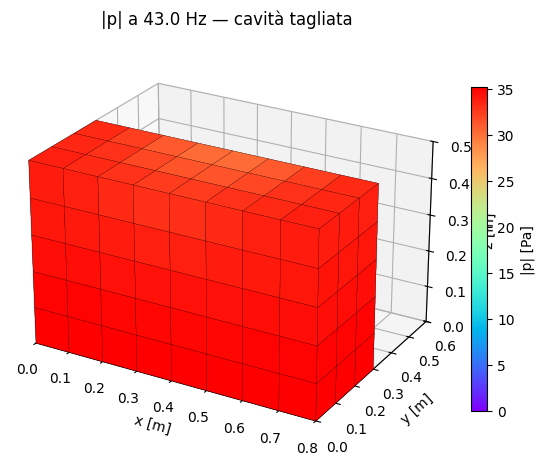

(<Figure size 700x600 with 2 Axes>,
 <Axes3D: title={'center': '|p| a 43.0 Hz — cavità tagliata'}, xlabel='x [m]', ylabel='y [m]', zlabel='z [m]'>)

In [12]:
# Campo di pressione 3D alla risonanza del caso incastrato
out = risposte["C-C-C-C"]
picco = int(np.argmax(np.abs(out["w"][out["dof"]])))
p_full = expand_pressure(out["p"], out["idx_a"], nodes.shape[0])

print(f"risonanza a {frequenze[picco]:.1f} Hz, "
      f"|p|max = {np.abs(p_full[:, picco]).max():.1f} Pa")

plot_pressure_3d(
    nodes, elements, p_full[:, picco],
    title=f"|p| a {frequenze[picco]:.1f} Hz — cavità tagliata",
    clip={"axis": "y", "keep": "<"},
)

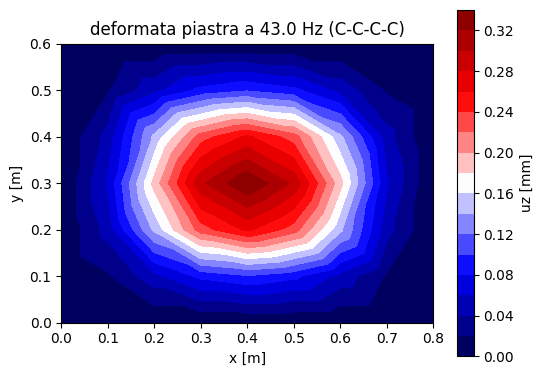

In [13]:
# Deformata della piastra alla risonanza
w_field = structural_displacement_field(
    out["w"][:, picco], out["idx_s"], nodes.shape[0]
)
piastra = casi["C-C-C-C"]["sistema"]["structural"]["nodes0"]
uz = np.real(w_field[piastra, 2])

plt.figure(figsize=(6, 4.5))
sc = plt.tricontourf(nodes[piastra, 0], nodes[piastra, 1], uz * 1e3,
                     levels=20, cmap="seismic")
plt.colorbar(sc, label="uz [mm]")
plt.gca().set_aspect("equal")
plt.xlabel("x [m]"); plt.ylabel("y [m]")
plt.title(f"deformata piastra a {frequenze[picco]:.1f} Hz (C-C-C-C)")
plt.show()

Movie saved: cavita_accoppiata.gif  (36 frames, 15 fps)


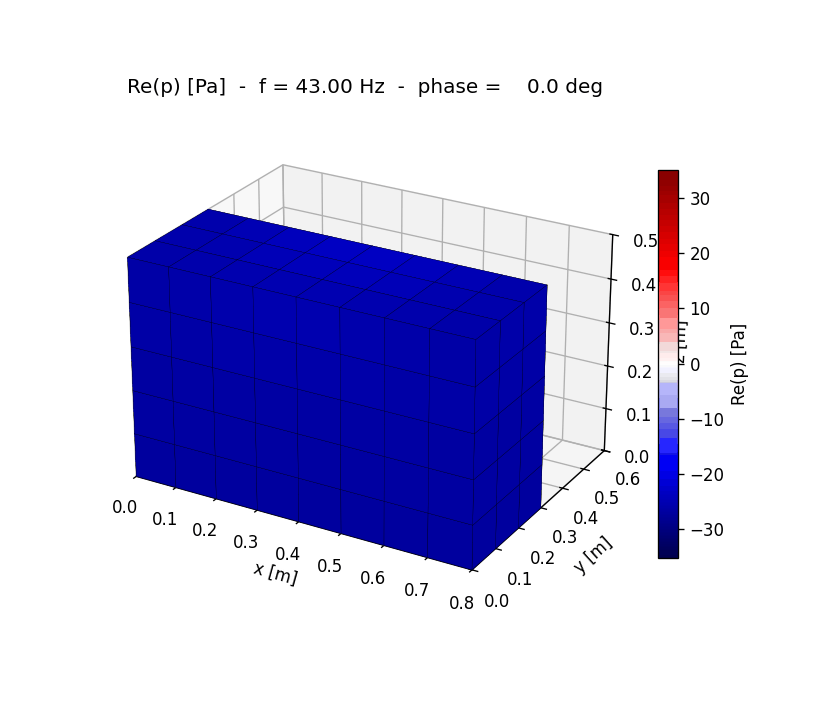

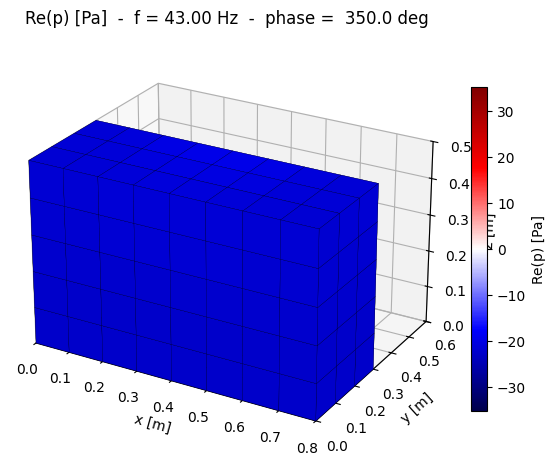

In [14]:
# Filmato: onda nella cavità alla risonanza, sezione tagliata.
# .mp4 se c'è ffmpeg nell'ambiente del kernel, altrimenti .gif
from IPython.display import HTML, Image

ext = default_movie_extension()
nome_file = f"cavita_accoppiata{ext}"

animate_pressure_3d(
    nodes, elements, p_full, frequenze,
    mode="time", freq_id=picco, n_time_steps=36,
    clip={"axis": "y", "keep": "<"},
    filename=nome_file, fps=15,
)

# il .gif si mostra inline, il video si apre dal file accanto al notebook
Image(nome_file) if ext == ".gif" else HTML(
    f'<video src="{nome_file}" controls loop width="600"></video>'
)

## Riepilogo

* $K_c$ si integra sulle facce condivise; la normale è orientata in automatico verso l'esterno del fluido, e `∫ n dS` recuperata da `Kc` è il controllo di coerenza.
* Il sistema accoppiato è **non simmetrico** perché mescola spostamenti e pressioni: pressione → forza nel blocco di rigidezza, accelerazione → sorgente nel blocco di massa.
* L'aria chiusa nella cavità è una molla: alza le frequenze dei modi che spazzano volume, mentre su quelli a $\Delta V \simeq 0$ prevale la massa aggiunta.
* Il vincolo di bordo cambia molto il quadro: una piastra **appoggiata** è più cedevole, spazza più volume e risente molto di più dell'accoppiamento di una **incastrata**.

Per provare altre configurazioni: `support="free"`, oppure `clamp_dofs=[2]` per bloccare solo la traslazione trasversale.